--- Iniciando el entrenamiento del modelo de severidad (Benchmark vs GPR Setup) ---
--- Cargando dataset YA PROCESADO ('revisedds.csv') ---
--- Usando LTO Cross-Validation con SMOTE global en fold ---

Dataset 'revisedds.csv' cargado. Forma: (386612, 30)
Covariables para preprocesamiento GLOBAL: ['Humidity_percent', 'Humidity_percent_extreme', 'Junction', 'Precipitation_in', 'Precipitation_in_extreme', 'Railway', 'Roundabout', 'Start_Lat', 'Start_Lng', 'Station', 'Stop', 'Temperature_F', 'Temperature_F_extreme', 'Traffic_Signal', 'Wind_Speed_mph', 'Wind_Speed_mph_extreme', 'accident_count', 'is_night', 'is_weekend', 'lat_bin', 'lat_max', 'lat_min', 'lng_bin', 'lng_max', 'lng_min', 'temporal_id_numeric']
Nombres de covariables procesadas GLOBALMENTE: ['Humidity_percent', 'Humidity_percent_extreme', 'Junction', 'Precipitation_in', 'Precipitation_in_extreme', 'Railway', 'Roundabout', 'Start_Lat', 'Start_Lng', 'Station', 'Stop', 'Temperature_F', 'Temperature_F_extreme', 'Traffic_Signal', '

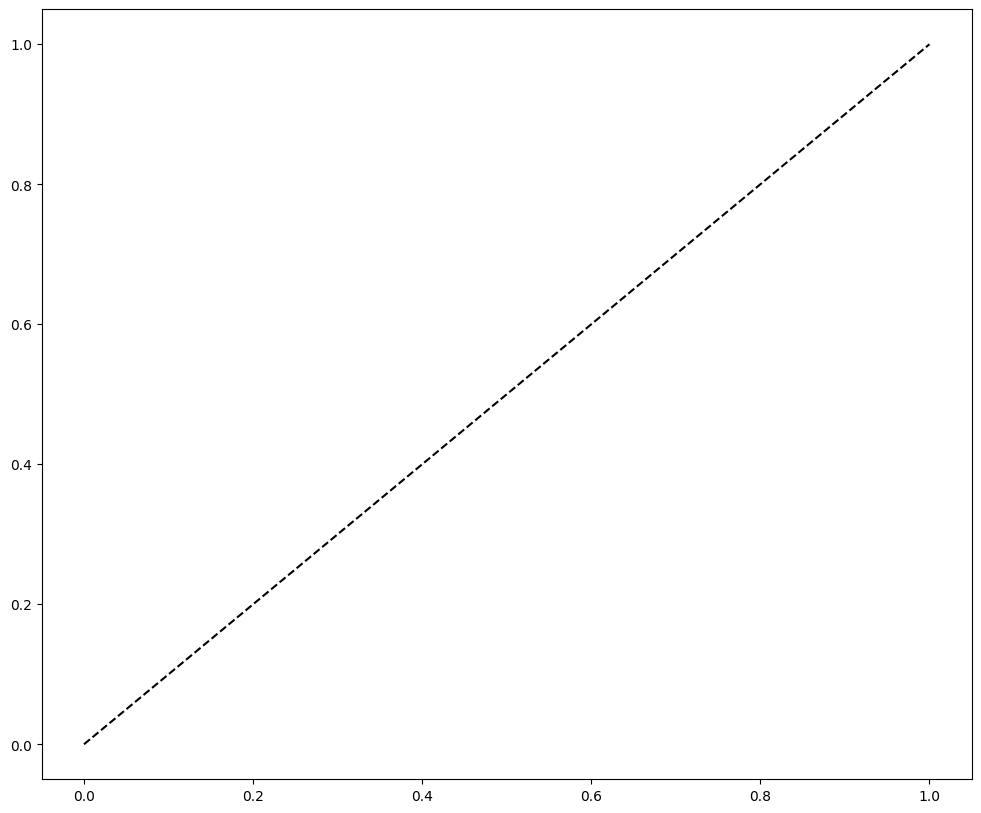

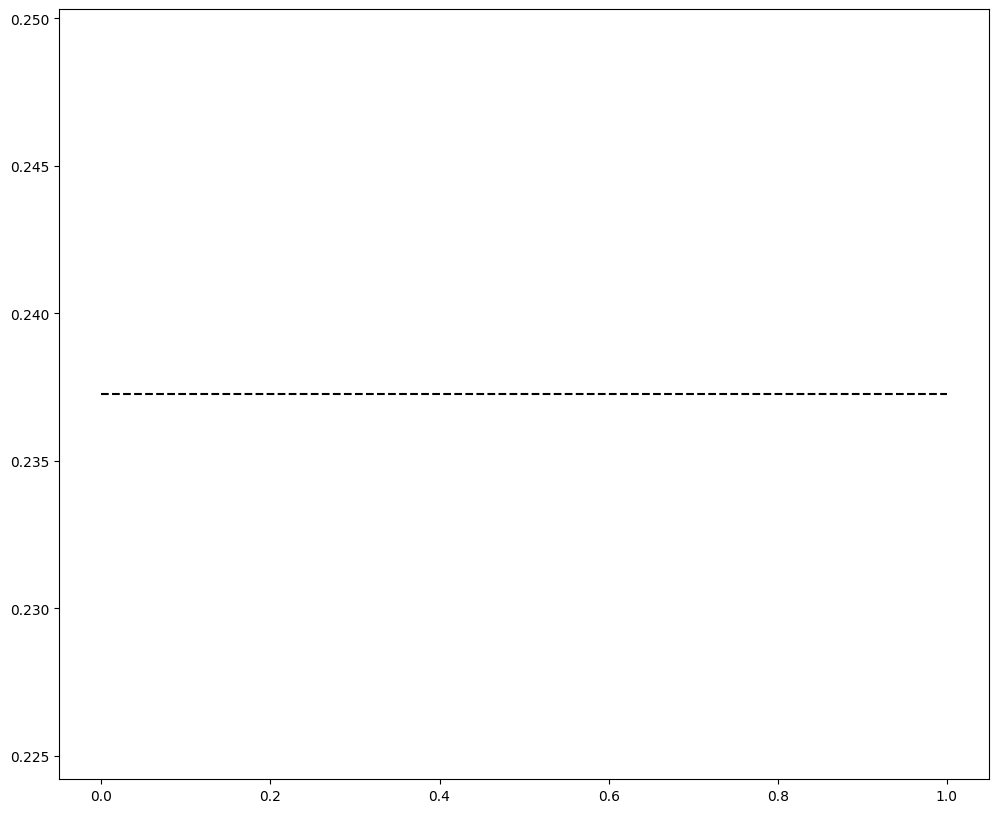

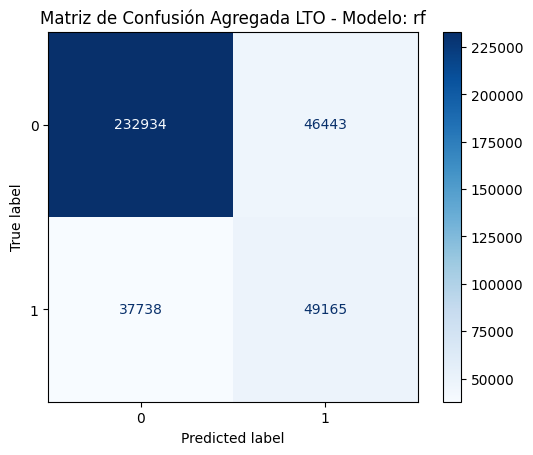

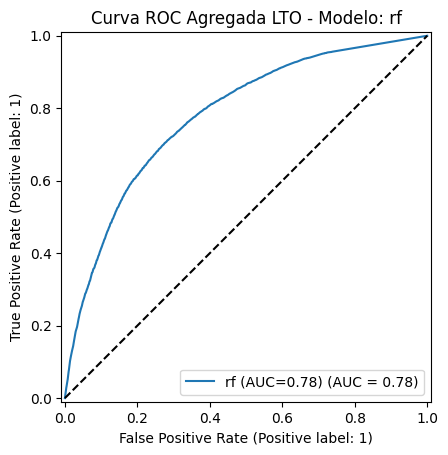

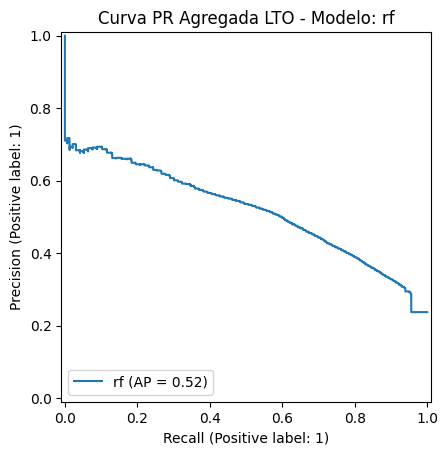


--- Modelo: xgb (Rendimiento Agregado LTO) ---
  Reporte de Clasificación (Agregado LTO):
              precision    recall  f1-score   support

     Clase 0       0.89      0.74      0.81    279377
     Clase 1       0.45      0.71      0.55     86903

    accuracy                           0.73    366280
   macro avg       0.67      0.72      0.68    366280
weighted avg       0.79      0.73      0.75    366280



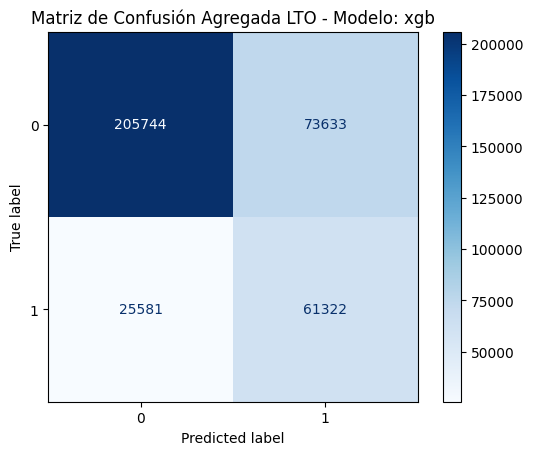

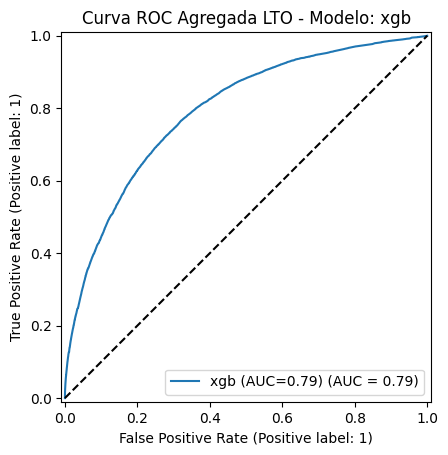

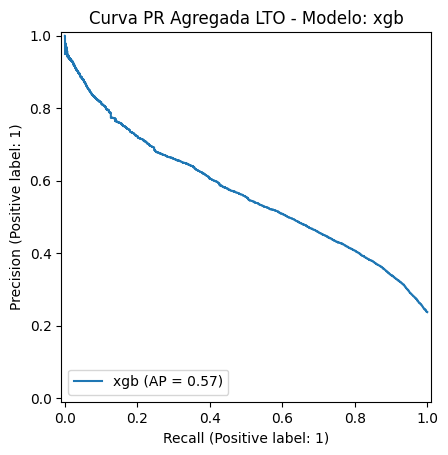


--- Modelo: logreg (Rendimiento Agregado LTO) ---
  Reporte de Clasificación (Agregado LTO):
              precision    recall  f1-score   support

     Clase 0       0.87      0.72      0.79    279377
     Clase 1       0.42      0.65      0.51     86903

    accuracy                           0.71    366280
   macro avg       0.65      0.69      0.65    366280
weighted avg       0.76      0.71      0.72    366280



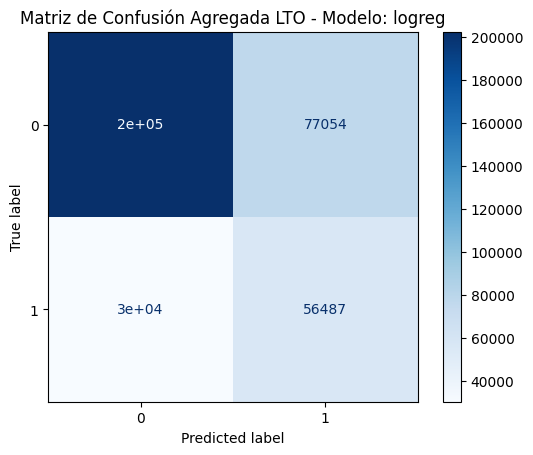

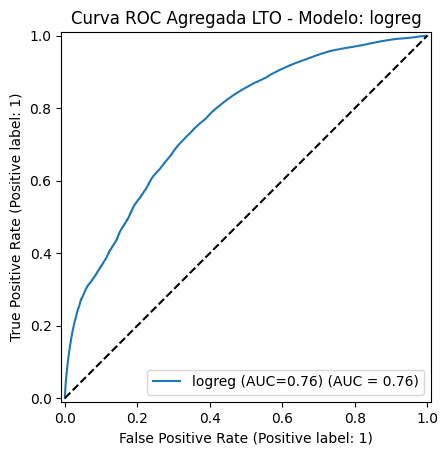

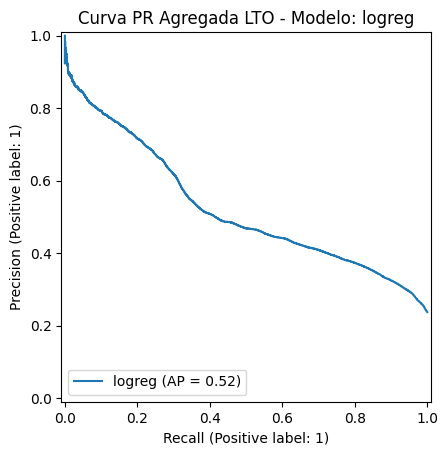


--- Modelo: sgd_log (Rendimiento Agregado LTO) ---
  Reporte de Clasificación (Agregado LTO):
              precision    recall  f1-score   support

     Clase 0       0.86      0.74      0.80    279377
     Clase 1       0.43      0.62      0.51     86903

    accuracy                           0.71    366280
   macro avg       0.65      0.68      0.65    366280
weighted avg       0.76      0.71      0.73    366280



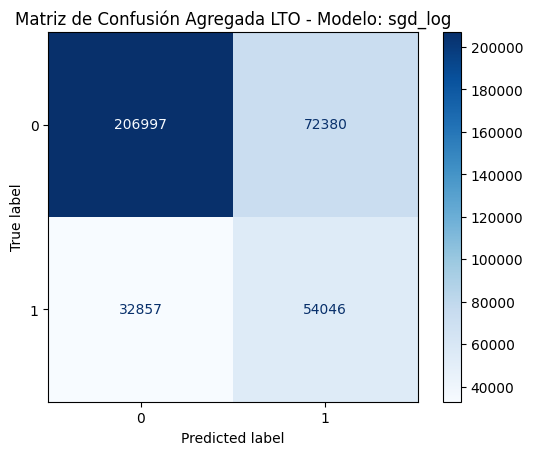

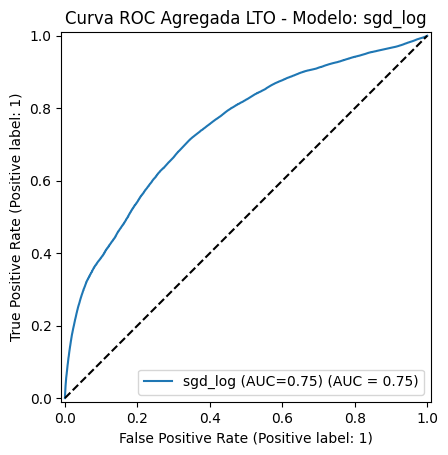

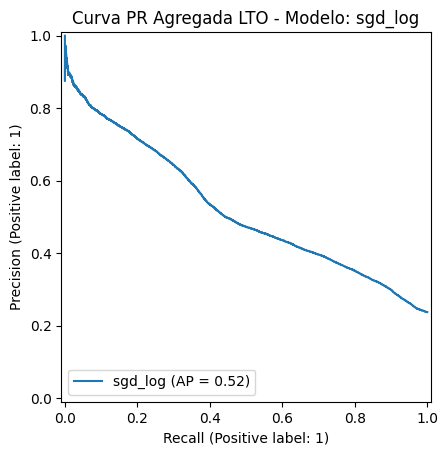


--- Modelo: gaussian_nb (Rendimiento Agregado LTO) ---
  Reporte de Clasificación (Agregado LTO):
              precision    recall  f1-score   support

     Clase 0       0.85      0.90      0.87    279377
     Clase 1       0.61      0.47      0.53     86903

    accuracy                           0.80    366280
   macro avg       0.73      0.69      0.70    366280
weighted avg       0.79      0.80      0.79    366280



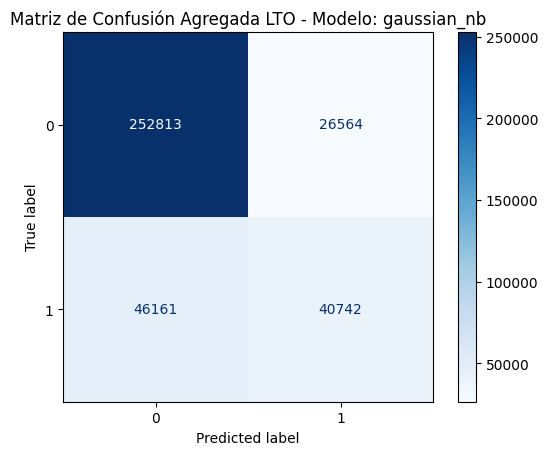

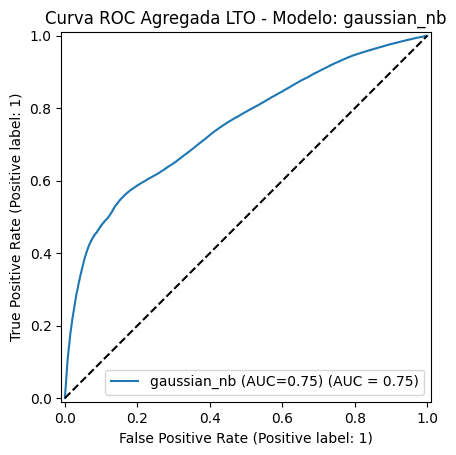

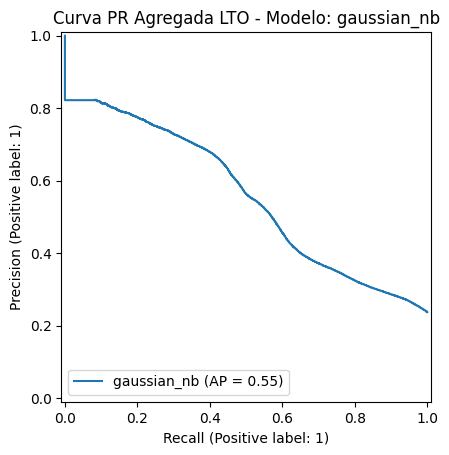


--- Modelo: knn (Rendimiento Agregado LTO) ---
  Reporte de Clasificación (Agregado LTO):
              precision    recall  f1-score   support

     Clase 0       0.87      0.85      0.86    279377
     Clase 1       0.55      0.58      0.56     86903

    accuracy                           0.79    366280
   macro avg       0.71      0.72      0.71    366280
weighted avg       0.79      0.79      0.79    366280



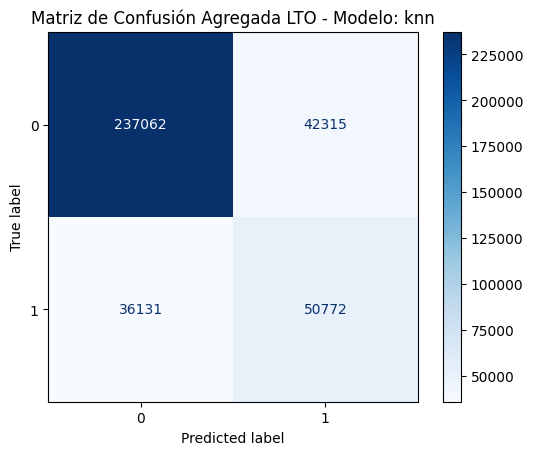

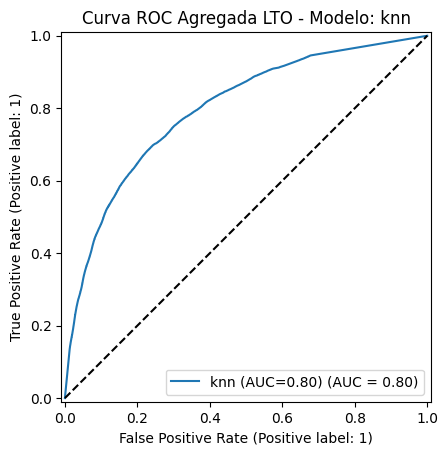

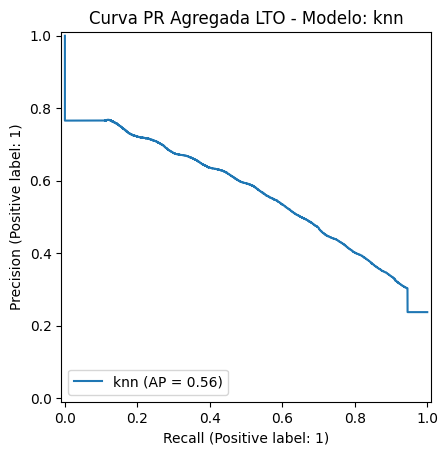


--- Preparando Reentrenamiento para Hold-out Final (logreg) ---
Datos de reentrenamiento: hasta antes del periodo temporal_id 1.4475552912658125 (371085 muestras)
Datos de Hold-out: desde el periodo temporal_id 1.4475552912658125 en adelante (15527 muestras)
   Aplicando SMOTE al conjunto de reentrenamiento final (k=5, strategy=0.5)...
Reentrenando logreg en 413101 muestras (después de SMOTE)...

--- Evaluación del Hold-out Final ---
              precision    recall  f1-score   support

     Clase 0       0.99      0.93      0.96     15358
     Clase 1       0.05      0.36      0.09       169

    accuracy                           0.92     15527
   macro avg       0.52      0.64      0.52     15527
weighted avg       0.98      0.92      0.95     15527



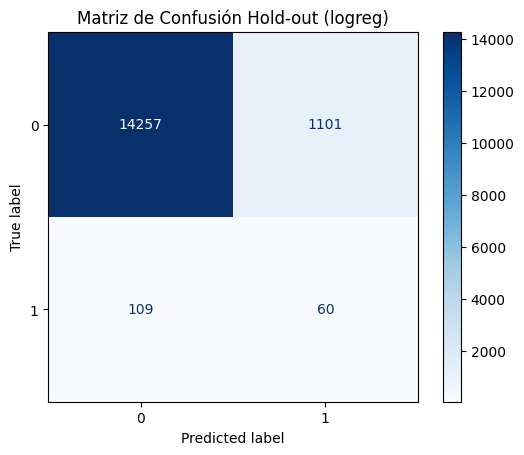

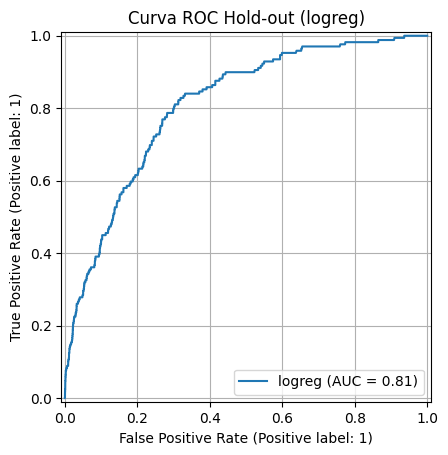

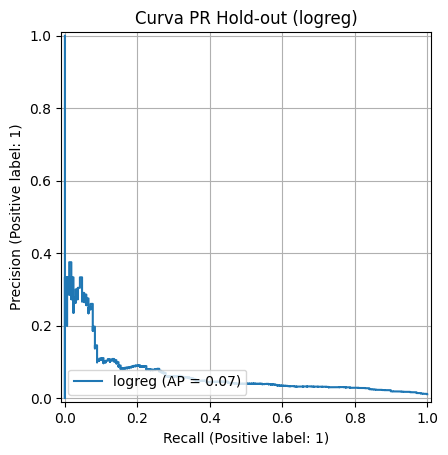

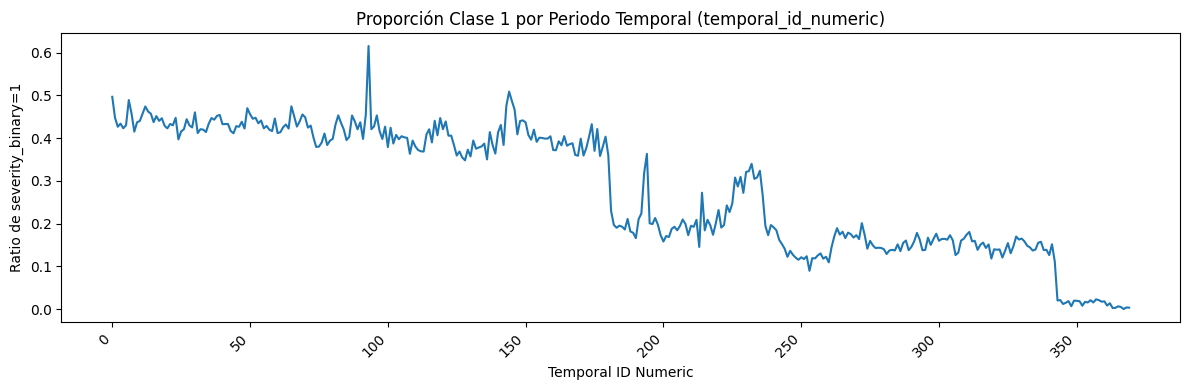


--- Proceso de modelado (estilo GPR) completado exitosamente! ---


In [2]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# --- Helper Functions (from GPR scripts) ---
def parse_spatial_temporal_ids_for_gpr(df, temporal_raw_col='year_week', spatial_raw_col='zone_id'):
    df_copy = df.copy()
    if spatial_raw_col not in df_copy.columns:
        raise ValueError(f"Spatial ID column '{spatial_raw_col}' not found in input DataFrame.")
    df_copy['spatial_id'] = df_copy[spatial_raw_col].astype(str)

    if temporal_raw_col not in df_copy.columns:
        raise ValueError(f"Temporal ID column '{temporal_raw_col}' not found in input DataFrame.")
    unique_temporal_ids = sorted(df_copy[temporal_raw_col].unique())
    temporal_id_to_numeric_map = {yw: i for i, yw in enumerate(unique_temporal_ids)}
    df_copy['temporal_id_numeric'] = df_copy[temporal_raw_col].map(temporal_id_to_numeric_map)
    df_copy.sort_values(by=['spatial_id', 'temporal_id_numeric'], inplace=True)
    return df_copy

def clean_col_names_for_gpr(df, cols_to_clean):
    df_cleaned = df.copy()
    rename_map = {}
    cleaned_cols_list = []
    if not isinstance(cols_to_clean, list): cols_to_clean = []
    for col in cols_to_clean:
        if col is None or col not in df_cleaned.columns: continue
        new_col_name = str(col).replace('(F)', '_F') \
            .replace('(mph)', '_mph') \
            .replace('(in)', '_in') \
            .replace('(%)', '_percent') \
            .replace('[', '_').replace(']', '_') \
            .replace('(', '').replace(')', '') \
            .replace('%', 'percent').replace('/', '_').replace('-', '_') \
            .replace('.', '_')
        rename_map[col] = new_col_name
        cleaned_cols_list.append(new_col_name)
    df_cleaned.rename(columns=rename_map, inplace=True)
    return df_cleaned, cleaned_cols_list, rename_map

# --- Global Preprocessing Function ---
def preprocess_features_globally(df, covar_cols_to_use, numeric_strategy='mean'):
    processed_df = df.copy()
    valid_covar_cols = [col for col in covar_cols_to_use if col in processed_df.columns]

    if not valid_covar_cols:
        print("Warning: No valid covariate columns found to preprocess globally.")
        return processed_df, []

    processed_covar_names = []
    numeric_covars = processed_df[valid_covar_cols].select_dtypes(include=np.number).columns.tolist()
    categorical_covars = processed_df[valid_covar_cols].select_dtypes(exclude=np.number).columns.tolist()

    if numeric_covars:
        imputer_mean = SimpleImputer(strategy=numeric_strategy)
        scaler = StandardScaler()
        if processed_df[numeric_covars].isnull().values.any():
            processed_df[numeric_covars] = imputer_mean.fit_transform(processed_df[numeric_covars])
        if len(numeric_covars) > 0:
            processed_df[numeric_covars] = scaler.fit_transform(processed_df[numeric_covars])
        processed_covar_names.extend(numeric_covars)

    if categorical_covars:
        print(f"Warning: Categorical covariates found in global preprocessing: {categorical_covars}. Factorizing them.")
        imputer_mode = SimpleImputer(strategy='most_frequent')
        for col in categorical_covars:
            if processed_df[col].isnull().any():
                processed_df[col] = imputer_mode.fit_transform(processed_df[[col]]).ravel()
            processed_df[col] = pd.factorize(processed_df[col].astype(str))[0]
            processed_covar_names.append(col)
    
    final_processed_names = [col for col in valid_covar_cols if col in processed_df.columns and col in processed_covar_names]
    return processed_df, final_processed_names


print("--- Iniciando el entrenamiento del modelo de severidad (Benchmark vs GPR Setup) ---")
print("--- Cargando dataset YA PROCESADO ('revisedds.csv') ---")
print("--- Usando LTO Cross-Validation con SMOTE global en fold ---")

try:
    df_full_original = pd.read_csv('revisedds.csv')
except FileNotFoundError:
    print("ERROR: El archivo 'revisedds.csv' no se encontró. Verifica la ruta.")
    exit()

print(f"\nDataset 'revisedds.csv' cargado. Forma: {df_full_original.shape}")

target_col_name_original = 'severity_binary'
spatial_id_col_name_original = 'zone_id'
temporal_raw_col_name_original = 'year_week'

covariate_list_original = [
    'accident_count', 'Temperature(F)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Humidity(%)',
    'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal',
    'is_night', 'is_weekend', 'Temperature(F)_extreme', 'Wind_Speed(mph)_extreme',
    'Precipitation(in)_extreme', 'Humidity(%)_extreme',
    'Start_Lat', 'Start_Lng', 'lat_bin', 'lng_bin',
    'lat_min', 'lat_max', 'lng_min', 'lng_max',
]
covariate_list_original = [col for col in covariate_list_original if col in df_full_original.columns]

all_cols_to_clean_check = covariate_list_original + \
                          [target_col_name_original, spatial_id_col_name_original, temporal_raw_col_name_original]
all_cols_to_clean_check = list(set([col for col in all_cols_to_clean_check if col in df_full_original.columns]))

df_cleaned_names, _, raw_to_cleaned_map = clean_col_names_for_gpr(df_full_original.copy(), all_cols_to_clean_check)

target_col_cleaned = raw_to_cleaned_map.get(target_col_name_original, target_col_name_original)
spatial_id_col_for_parse = raw_to_cleaned_map.get(spatial_id_col_name_original, spatial_id_col_name_original)
temporal_raw_col_for_parse = raw_to_cleaned_map.get(temporal_raw_col_name_original, temporal_raw_col_name_original)

df_with_ids = parse_spatial_temporal_ids_for_gpr(
    df_cleaned_names.copy(),
    temporal_raw_col=temporal_raw_col_for_parse,
    spatial_raw_col=spatial_id_col_for_parse
)

if 'temporal_id_numeric' not in df_with_ids.columns:
    raise ValueError("'temporal_id_numeric' no fue creada. Revisa 'temporal_raw_col_for_parse'.")
if 'spatial_id' not in df_with_ids.columns:
    raise ValueError("'spatial_id' no fue creada. Revisa 'spatial_id_col_for_parse'.")

covariate_list_for_global_processing = [raw_to_cleaned_map.get(col, col) for col in covariate_list_original]
if 'temporal_id_numeric' not in covariate_list_for_global_processing:
    covariate_list_for_global_processing.append('temporal_id_numeric')
covariate_list_for_global_processing = [
    col for col in covariate_list_for_global_processing
    if col in df_with_ids.columns and col != target_col_cleaned
]
covariate_list_for_global_processing = sorted(list(set(covariate_list_for_global_processing)))

print(f"Covariables para preprocesamiento GLOBAL: {covariate_list_for_global_processing}")
df_globally_preprocessed, processed_covariate_names = preprocess_features_globally(
    df_with_ids.copy(),
    covariate_list_for_global_processing
)
print(f"Nombres de covariables procesadas GLOBALMENTE: {processed_covariate_names}")

if target_col_cleaned not in df_globally_preprocessed.columns:
    raise ValueError(f"La columna objetivo '{target_col_cleaned}' no está en el DataFrame preprocesado.")
y_series_full = df_globally_preprocessed[target_col_cleaned].astype(int)
X_df_full = df_globally_preprocessed.drop(columns=[target_col_cleaned], errors='ignore')

print(f"\nForma final de X para LTO: {X_df_full.shape}")
print(f"Forma final de y para LTO: {y_series_full.shape}")
print(f"Distribución de la clase objetivo (y_series_full):\n{y_series_full.value_counts(normalize=True)}")

if X_df_full.empty or y_series_full.empty:
    print("ERROR: X_df_full o y_series_full están vacíos antes de LTO. No se puede continuar.")
    exit()
if 'temporal_id_numeric' not in X_df_full.columns:
    raise ValueError("ERROR: 'temporal_id_numeric' falta en X_df_full antes de LTO.")

unique_temporal_ids = np.sort(X_df_full['temporal_id_numeric'].unique())
n_total_temporal_periods = len(unique_temporal_ids)
LTO_MAX_TRAIN_WINDOW_PERIODS = 26
n_splits_lto = 10

if n_total_temporal_periods <= LTO_MAX_TRAIN_WINDOW_PERIODS:
    exit(f"ERROR: Periodos temporales totales ({n_total_temporal_periods}) no es mayor que la ventana máx de entrenamiento ({LTO_MAX_TRAIN_WINDOW_PERIODS}).")

num_testable_periods_total = n_total_temporal_periods - LTO_MAX_TRAIN_WINDOW_PERIODS
if num_testable_periods_total < n_splits_lto:
    n_splits_lto = max(1, num_testable_periods_total)
    if n_splits_lto == 0: exit("ERROR: No quedan datos para folds de prueba.")
    print(f"ADVERTENCIA: n_splits_lto ajustado a {n_splits_lto} debido a datos insuficientes para prueba.")

test_fold_size_temporal_periods = num_testable_periods_total // n_splits_lto if n_splits_lto > 0 else 0
if test_fold_size_temporal_periods == 0 and num_testable_periods_total > 0:
    test_fold_size_temporal_periods = 1
if test_fold_size_temporal_periods == 0:
    exit("ERROR: No se pueden crear folds de prueba de tamaño 0.")

print(f"\n--- Iniciando LTO Cross-Validation con {n_splits_lto} folds (Ventana Deslizante) ---")
print(f"Tamaño máx ventana de entrenamiento: {LTO_MAX_TRAIN_WINDOW_PERIODS} periodos temporales")
print(f"Tamaño fold de prueba: {test_fold_size_temporal_periods} periodos temporales")

gp_feature_set_to_use = [
    'temporal_id_numeric',
    raw_to_cleaned_map.get('accident_count', 'accident_count'),
    raw_to_cleaned_map.get('Temperature(F)', 'Temperature_F'),
    raw_to_cleaned_map.get('Precipitation(in)', 'Precipitation_in'),
    raw_to_cleaned_map.get('is_night', 'is_night'),
    raw_to_cleaned_map.get('is_weekend', 'is_weekend')
]
gp_feature_set_to_use = [f for f in gp_feature_set_to_use if f in X_df_full.columns]
gp_feature_set_to_use = sorted(list(set(gp_feature_set_to_use)))

if not gp_feature_set_to_use:
    raise ValueError("ERROR: `gp_feature_set_to_use` está vacía o las características no se encontraron en X_df_full.")
print(f"Características seleccionadas para los modelos (después de LTO split, antes de SMOTE): {gp_feature_set_to_use}")

pos_weight_scale = (y_series_full == 0).sum() / (y_series_full == 1).sum() if (y_series_full == 1).sum() > 0 else 1
model_defs = {
    'rf': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample'),
    'xgb': XGBClassifier(random_state=42, tree_method='hist', n_jobs=-1, scale_pos_weight=pos_weight_scale),
    'logreg': LogisticRegression(max_iter=1000, solver='saga', random_state=42, n_jobs=-1, class_weight='balanced', penalty='l1'),
    'sgd_log': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced', early_stopping=True, n_iter_no_change=10, validation_fraction=0.1),
    'gaussian_nb': GaussianNB(),
    'knn': KNeighborsClassifier(n_neighbors=11, n_jobs=-1, weights='distance')
}

smote_sampling_strategy = 0.5
smote_k_neighbors = 5

model_predictions_aggregated = {model_name: {'y_true': [], 'y_pred': [], 'y_proba': [], 'name': model_name} for model_name in model_defs.keys()}
all_fold_model_metrics = []

for i in range(n_splits_lto):
    fold_start_time = time.time()
    print(f"\n=== Procesando LTO Fold {i+1}/{n_splits_lto} ===")

    current_test_start_idx_in_unique_ids = LTO_MAX_TRAIN_WINDOW_PERIODS + (i * test_fold_size_temporal_periods)
    current_test_end_idx_in_unique_ids = current_test_start_idx_in_unique_ids + test_fold_size_temporal_periods
    if i == n_splits_lto - 1:
        current_test_end_idx_in_unique_ids = n_total_temporal_periods
    
    current_test_temporal_ids = unique_temporal_ids[current_test_start_idx_in_unique_ids : current_test_end_idx_in_unique_ids]
    if len(current_test_temporal_ids) == 0:
        print("Fold de prueba vacío, saltando.")
        continue

    train_window_end_temporal_id_exclusive_val = current_test_temporal_ids.min()
    idx_train_end = np.searchsorted(unique_temporal_ids, train_window_end_temporal_id_exclusive_val)
    idx_train_start = max(0, idx_train_end - LTO_MAX_TRAIN_WINDOW_PERIODS)
    train_window_start_temporal_id_inclusive_val = unique_temporal_ids[idx_train_start]

    current_train_temporal_ids = unique_temporal_ids[
        (unique_temporal_ids >= train_window_start_temporal_id_inclusive_val) &
        (unique_temporal_ids < train_window_end_temporal_id_exclusive_val)
    ]
    if len(current_train_temporal_ids) == 0:
        print("Fold de entrenamiento vacío, saltando.")
        continue

    train_mask = X_df_full['temporal_id_numeric'].isin(current_train_temporal_ids)
    test_mask = X_df_full['temporal_id_numeric'].isin(current_test_temporal_ids)

    X_train_fold_full_features = X_df_full[train_mask].copy()
    y_train_fold_series = y_series_full[train_mask].copy()
    X_test_fold_full_features = X_df_full[test_mask].copy()
    y_test_fold_series = y_series_full[test_mask].copy()
    
    print(f"   Entrenar en {len(current_train_temporal_ids)} periodos temporales únicos (de {current_train_temporal_ids.min() if len(current_train_temporal_ids)>0 else 'N/A'} a {current_train_temporal_ids.max() if len(current_train_temporal_ids)>0 else 'N/A'})")
    print(f"   Probar en {len(current_test_temporal_ids)} periodos temporales únicos (de: {current_test_temporal_ids.min()} a {current_test_temporal_ids.max()})")
    print(f"   Muestras de entrenamiento (antes de selección de feat.): {len(X_train_fold_full_features)}, Muestras de prueba: {len(X_test_fold_full_features)}")

    if len(X_train_fold_full_features) < 10 or y_train_fold_series.nunique() < 2:
        print("   Saltando fold: datos insuficientes o solo una clase en el conjunto de entrenamiento.")
        continue

    X_train_selected_features = X_train_fold_full_features[gp_feature_set_to_use]
    X_test_selected_features = X_test_fold_full_features[gp_feature_set_to_use]
    
    print(f"   Forma de X_train después de seleccionar características: {X_train_selected_features.shape}")
    print(f"   Distribución y_train_fold_series (antes de SMOTE):\n{y_train_fold_series.value_counts(normalize=True).to_dict()}")

    X_train_smoted, y_train_smoted = X_train_selected_features, y_train_fold_series
    minority_count_train = y_train_fold_series.value_counts().min()
    k_neigh_actual_smote = min(smote_k_neighbors, minority_count_train - 1) if minority_count_train > 1 else 1

    if k_neigh_actual_smote >= 1 and minority_count_train > k_neigh_actual_smote :
        print(f"   Aplicando SMOTE (k={k_neigh_actual_smote}, strategy={smote_sampling_strategy})...")
        smote_applicator = SMOTE(sampling_strategy=smote_sampling_strategy, random_state=42, k_neighbors=k_neigh_actual_smote)
        try:
            X_train_smoted, y_train_smoted = smote_applicator.fit_resample(X_train_selected_features, y_train_fold_series)
            print(f"   Forma de X_train después de SMOTE: {X_train_smoted.shape}")
            print(f"   Distribución y_train_smoted:\n{pd.Series(y_train_smoted).value_counts(normalize=True).to_dict()}")
        except ValueError as e_smote:
            print(f"   Error durante SMOTE: {e_smote}. Usando datos originales para este fold.")
            X_train_smoted, y_train_smoted = X_train_selected_features, y_train_fold_series
    else:
        print(f"   SMOTE no aplicable o no necesario (minority_count={minority_count_train}, k_neigh={k_neigh_actual_smote}). Usando datos originales.")

    for model_name, clf_instance in model_defs.items():
        print(f"      Entrenando {model_name}...")
        pipeline_start_time = time.time()
        
        current_clf = type(clf_instance)()
        current_clf.set_params(**clf_instance.get_params())

        try:
            current_clf.fit(X_train_smoted, y_train_smoted)
            fit_end_time = time.time()
            print(f"         Ajuste de {model_name} tomó: {fit_end_time - pipeline_start_time:.2f} segundos")

            y_pred_test = current_clf.predict(X_test_selected_features)
            y_proba_test = None
            if hasattr(current_clf, 'predict_proba'):
                y_proba_test = current_clf.predict_proba(X_test_selected_features)[:,1]
            elif hasattr(current_clf, 'decision_function'):
                y_proba_test = current_clf.decision_function(X_test_selected_features)
                if y_proba_test is not None and (y_proba_test.min() < 0 or y_proba_test.max() > 1):
                    y_proba_test = (y_proba_test - y_proba_test.min()) / (y_proba_test.max() - y_proba_test.min()) if (y_proba_test.max() - y_proba_test.min()) > 0 else np.full_like(y_proba_test, 0.5)


            f1 = f1_score(y_test_fold_series, y_pred_test, zero_division=0)
            roc = np.nan
            if y_proba_test is not None and y_test_fold_series.nunique() > 1 :
                try: roc = roc_auc_score(y_test_fold_series, y_proba_test)
                except ValueError as e_roc:
                    print(f"         Error calculando ROC AUC para {model_name}: {e_roc}")
                    roc = np.nan
            acc = accuracy_score(y_test_fold_series, y_pred_test)

            model_predictions_aggregated[model_name]['y_true'].extend(y_test_fold_series.tolist())
            model_predictions_aggregated[model_name]['y_pred'].extend(y_pred_test.tolist())
            if y_proba_test is not None:
                if isinstance(y_proba_test, (np.ndarray, pd.Series)):
                    model_predictions_aggregated[model_name]['y_proba'].extend(y_proba_test.tolist())
                else:
                    model_predictions_aggregated[model_name]['y_proba'].extend([y_proba_test] * len(y_pred_test))
            else:
                model_predictions_aggregated[model_name]['y_proba'].extend([np.nan] * len(y_pred_test))

            all_fold_model_metrics.append({
                'fold': i+1, 'model': model_name,
                'f1': f1, 'roc_auc': roc, 'accuracy': acc,
                'train_samples_smoted': len(y_train_smoted),
                'test_samples': len(y_test_fold_series)
            })
            print(f"      {model_name} -> F1: {f1:.4f}, ROC_AUC: {roc:.4f}, Acc: {acc:.4f}")

        except Exception as e_model:
            print(f"      ERROR entrenando/evaluando {model_name}: {e_model}")
            all_fold_model_metrics.append({
                'fold': i+1, 'model': model_name,
                'f1': np.nan, 'roc_auc': np.nan, 'accuracy': np.nan,
                'train_samples_smoted': len(y_train_smoted) if 'y_train_smoted' in locals() else len(X_train_selected_features),
                'test_samples': len(y_test_fold_series)
            })
    print(f"--- Fold {i+1} completado en {time.time() - fold_start_time:.2f} segundos ---")

if all_fold_model_metrics:
    df_all_fold_model_metrics = pd.DataFrame(all_fold_model_metrics)
    print("\n--- Promedio de Métricas LTO por Modelo (Media y Desviación Estándar) ---")
    average_model_performance = df_all_fold_model_metrics.groupby('model')[['f1','roc_auc','accuracy']].agg(['mean', 'std'])
    print(average_model_performance.sort_values(by=('roc_auc', 'mean'), ascending=False))

    best_model_name_avg = None
    if not average_model_performance[('roc_auc', 'mean')].dropna().empty:
        best_model_name_avg = average_model_performance[('roc_auc', 'mean')].idxmax()
        print(f"\nMejor modelo en promedio (basado en media de ROC_AUC en LTO): {best_model_name_avg}")
        print("Métricas promedio del mejor modelo (media y std):")
        print(average_model_performance.loc[best_model_name_avg])
    else:
        print("\nNo hay métricas ROC_AUC válidas de LTO para seleccionar mejor modelo promedio. Usando RandomForest por defecto para Hold-out.")
        best_model_name_avg = 'rf'
        if best_model_name_avg in average_model_performance.index:
             print("Métricas promedio del modelo fallback (RandomForest):")
             print(average_model_performance.loc[best_model_name_avg])
    
    # --- Visualización Agregada del Rendimiento de Cada Modelo (Todos los Folds LTO Combinados) ---
    print("\n\n--- ANÁLISIS VISUAL DEL RENDIMIENTO AGREGADO POR MODELO (SOBRE TODOS LOS FOLDS LTO) ---")

    fig_roc_all, ax_roc_all = plt.subplots(figsize=(12, 10)) # Ajuste tamaño
    ax_roc_all.plot([0, 1], [0, 1], 'k--', label='Suerte (AUC = 0.5)')

    fig_pr_all, ax_pr_all = plt.subplots(figsize=(12, 10)) # Ajuste tamaño
    temp_all_y_true_for_baseline = []
    for model_key_for_baseline in model_predictions_aggregated:
        temp_all_y_true_for_baseline.extend(model_predictions_aggregated[model_key_for_baseline]['y_true'])
    if temp_all_y_true_for_baseline:
        no_skill_pr = len([x for x in temp_all_y_true_for_baseline if x == 1]) / len(temp_all_y_true_for_baseline) if len(temp_all_y_true_for_baseline) > 0 else 0.0
        ax_pr_all.plot([0, 1], [no_skill_pr, no_skill_pr], 'k--', label=f'No Skill (AP = {no_skill_pr:.2f})')
    del temp_all_y_true_for_baseline


    for model_name_viz, data_viz in model_predictions_aggregated.items():
        print(f"\n--- Modelo: {data_viz['name']} (Rendimiento Agregado LTO) ---")
        
        y_true_agg_viz = np.array(data_viz['y_true'])
        y_pred_agg_viz = np.array(data_viz['y_pred'])
        y_proba_agg_viz = np.array(data_viz['y_proba'])

        if len(y_true_agg_viz) == 0 or len(y_pred_agg_viz) == 0:
            print("  No hay predicciones agregadas para mostrar para este modelo.")
            continue

        unique_labels_viz = sorted(list(np.unique(y_true_agg_viz)))
        if not unique_labels_viz or len(unique_labels_viz) < 2: # Asegurar al menos dos etiquetas para métricas binarias
            unique_labels_viz = [0, 1] 
        target_names_viz = [f"Clase {l}" for l in unique_labels_viz]

        print("  Reporte de Clasificación (Agregado LTO):")
        try:
            print(classification_report(y_true_agg_viz, y_pred_agg_viz, labels=unique_labels_viz, target_names=target_names_viz, zero_division=0))
        except Exception as e_cr_viz:
            print(f"    No se pudo generar el reporte de clasificación agregado: {e_cr_viz}")

        try:
            cm_agg_viz = confusion_matrix(y_true_agg_viz, y_pred_agg_viz, labels=unique_labels_viz)
            disp_cm_viz = ConfusionMatrixDisplay(confusion_matrix=cm_agg_viz, display_labels=unique_labels_viz)
            disp_cm_viz.plot(cmap='Blues')
            plt.title(f'Matriz de Confusión Agregada LTO - Modelo: {data_viz["name"]}')
            plt.show()
        except Exception as e_cm_viz:
            print(f"    No se pudo generar la matriz de confusión agregada para {data_viz['name']}: {e_cm_viz}")

        valid_proba_indices_viz = ~np.isnan(y_proba_agg_viz)
        y_true_for_curves_viz = y_true_agg_viz[valid_proba_indices_viz]
        y_proba_for_curves_viz = y_proba_agg_viz[valid_proba_indices_viz]

        if len(y_proba_for_curves_viz) == 0 or len(y_true_for_curves_viz) == 0:
            print(f"    No hay probabilidades válidas para curvas ROC/PR para {data_viz['name']}.")
        
        roc_auc_agg_value = np.nan
        if np.unique(y_true_for_curves_viz).size > 1 and len(y_proba_for_curves_viz) > 0:
            try:
                roc_auc_agg_value = roc_auc_score(y_true_for_curves_viz, y_proba_for_curves_viz)
                fig_roc_ind, ax_roc_ind = plt.subplots()
                RocCurveDisplay.from_predictions(y_true_for_curves_viz, y_proba_for_curves_viz, name=f"{data_viz['name']} (AUC={roc_auc_agg_value:.2f})", ax=ax_roc_ind)
                ax_roc_ind.plot([0, 1], [0, 1], 'k--')
                ax_roc_ind.set_title(f'Curva ROC Agregada LTO - Modelo: {data_viz["name"]}')
                plt.show()
                RocCurveDisplay.from_predictions(y_true_for_curves_viz, y_proba_for_curves_viz, name=f"{data_viz['name']} (AUC={roc_auc_agg_value:.2f})", ax=ax_roc_all)
            except ValueError as e_roc_viz_val:
                 print(f"    Advertencia Curva ROC para {data_viz['name']}: {e_roc_viz_val}.")
            except Exception as e_roc_viz:
                print(f"    No se pudo generar la curva ROC agregada para {data_viz['name']}: {e_roc_viz}")
        elif len(y_proba_for_curves_viz) > 0 :
             print(f"    No se puede generar la curva ROC para {data_viz['name']} (solo una clase presente en y_true después de filtrar NaNs en y_proba, o no hay suficientes muestras).")
        
        pos_label_viz = 1 if 1 in unique_labels_viz else (unique_labels_viz[-1] if unique_labels_viz else 1)
        if np.unique(y_true_for_curves_viz).size > 1 and pos_label_viz in np.unique(y_true_for_curves_viz) and len(y_proba_for_curves_viz) > 0:
            try:
                fig_pr_ind, ax_pr_ind = plt.subplots()
                PrecisionRecallDisplay.from_predictions(y_true_for_curves_viz, y_proba_for_curves_viz, name=f"{data_viz['name']}", pos_label=pos_label_viz, ax=ax_pr_ind)
                ax_pr_ind.set_title(f'Curva PR Agregada LTO - Modelo: {data_viz["name"]}')
                plt.show()
                PrecisionRecallDisplay.from_predictions(y_true_for_curves_viz, y_proba_for_curves_viz, name=f"{data_viz['name']}", pos_label=pos_label_viz, ax=ax_pr_all)
            except ValueError as e_pr_viz_val:
                 print(f"    Advertencia Curva PR para {data_viz['name']}: {e_pr_viz_val}.")
            except Exception as e_pr_viz:
                print(f"    No se pudo generar la curva PR agregada para {data_viz['name']}: {e_pr_viz}")
        elif len(y_proba_for_curves_viz) > 0 :
             print(f"    No se puede generar la curva PR para {data_viz['name']} (solo una clase presente en y_true, etiqueta positiva no encontrada, o no hay suficientes muestras).")

    ax_roc_all.set_title('Curvas ROC Comparativas (Rendimiento Agregado LTO)')
    ax_roc_all.legend(loc='lower right')
    ax_roc_all.grid(True)
    fig_roc_all.tight_layout()
    plt.show()

    ax_pr_all.set_title('Curvas Precision-Recall Comparativas (Rendimiento Agregado LTO)')
    ax_pr_all.legend(loc='best')
    ax_pr_all.grid(True)
    fig_pr_all.tight_layout()
    plt.show()

    # --- Hold-out Final ---
    if best_model_name_avg and best_model_name_avg in model_defs:
        best_clf_final_proto = model_defs[best_model_name_avg]
    else:
        print(f"ADVERTENCIA: El mejor modelo promedio '{best_model_name_avg}' no se encontró en model_defs o no fue determinado. Usando RandomForest por defecto para hold-out.")
        best_model_name_avg = 'rf'
        best_clf_final_proto = model_defs[best_model_name_avg]

    best_clf_final = type(best_clf_final_proto)()
    best_clf_final.set_params(**best_clf_final_proto.get_params())

    HOLDOUT_PERIODS = 13
    if n_total_temporal_periods <= HOLDOUT_PERIODS:
        print("No hay suficientes periodos para un hold-out separado con la configuración actual. Saltando hold-out.")
    else:
        holdout_start_temporal_id_idx = n_total_temporal_periods - HOLDOUT_PERIODS
        holdout_start_temporal_id = unique_temporal_ids[holdout_start_temporal_id_idx]

        mask_hold_final = X_df_full['temporal_id_numeric'] >= holdout_start_temporal_id
        mask_retrain_final = X_df_full['temporal_id_numeric'] < holdout_start_temporal_id

        X_hold_final_full_features = X_df_full[mask_hold_final]
        y_hold_final_series = y_series_full[mask_hold_final]
        X_retrain_final_full_features = X_df_full[mask_retrain_final]
        y_retrain_final_series = y_series_full[mask_retrain_final]

        print(f"\n--- Preparando Reentrenamiento para Hold-out Final ({best_model_name_avg}) ---")
        print(f"Datos de reentrenamiento: hasta antes del periodo temporal_id {holdout_start_temporal_id} ({len(X_retrain_final_full_features)} muestras)")
        print(f"Datos de Hold-out: desde el periodo temporal_id {holdout_start_temporal_id} en adelante ({len(X_hold_final_full_features)} muestras)")

        if X_retrain_final_full_features.empty or y_retrain_final_series.empty or X_hold_final_full_features.empty or y_hold_final_series.empty:
            print("ERROR: Conjuntos de reentrenamiento o hold-out vacíos. No se puede continuar con hold-out.")
        else:
            X_retrain_selected_features = X_retrain_final_full_features[gp_feature_set_to_use]
            X_hold_selected_features = X_hold_final_full_features[gp_feature_set_to_use]

            X_retrain_smoted, y_retrain_smoted = X_retrain_selected_features, y_retrain_final_series
            minority_count_retrain = y_retrain_final_series.value_counts().min()
            k_neigh_actual_smote_final = min(smote_k_neighbors, minority_count_retrain - 1) if minority_count_retrain > 1 else 1
            
            if k_neigh_actual_smote_final >=1 and minority_count_retrain > k_neigh_actual_smote_final:
                print(f"   Aplicando SMOTE al conjunto de reentrenamiento final (k={k_neigh_actual_smote_final}, strategy={smote_sampling_strategy})...")
                smote_final = SMOTE(sampling_strategy=smote_sampling_strategy, random_state=42, k_neighbors=k_neigh_actual_smote_final)
                try:
                    X_retrain_smoted, y_retrain_smoted = smote_final.fit_resample(X_retrain_selected_features, y_retrain_final_series)
                except ValueError as e_smote_final:
                    print(f"   Error SMOTE en reentrenamiento final: {e_smote_final}. Usando datos originales.")
                    X_retrain_smoted, y_retrain_smoted = X_retrain_selected_features, y_retrain_final_series
            else:
                print("   SMOTE no aplicable o no necesario para reentrenamiento final.")

            print(f"Reentrenando {best_model_name_avg} en {len(X_retrain_smoted)} muestras (después de SMOTE)...")
            best_clf_final.fit(X_retrain_smoted, y_retrain_smoted)

            print("\n--- Evaluación del Hold-out Final ---")
            y_hold_pred_final = best_clf_final.predict(X_hold_selected_features)
            
            final_unique_labels = sorted(list(np.unique(y_hold_final_series)))
            if not final_unique_labels or len(final_unique_labels) < 2: final_unique_labels = [0,1]
            final_target_names = [f"Clase {l}" for l in final_unique_labels]

            print(classification_report(y_hold_final_series, y_hold_pred_final, labels=final_unique_labels, target_names=final_target_names, zero_division=0))

            cm_final_labels = best_clf_final.classes_ if hasattr(best_clf_final, 'classes_') and len(best_clf_final.classes_)==2 else final_unique_labels
            cm_final = confusion_matrix(y_hold_final_series, y_hold_pred_final, labels=cm_final_labels)
            ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=cm_final_labels).plot(cmap=plt.cm.Blues)
            plt.title(f'Matriz de Confusión Hold-out ({best_model_name_avg})'); plt.show()

            y_proba_hold_final = None
            if hasattr(best_clf_final, 'predict_proba'):
                y_proba_hold_final = best_clf_final.predict_proba(X_hold_selected_features)[:,1]
            elif hasattr(best_clf_final, 'decision_function'):
                y_proba_hold_final = best_clf_final.decision_function(X_hold_selected_features)
                if y_proba_hold_final is not None and (y_proba_hold_final.min() < 0 or y_proba_hold_final.max() > 1):
                    y_proba_hold_final = (y_proba_hold_final - y_proba_hold_final.min()) / (y_proba_hold_final.max() - y_proba_hold_final.min()) if (y_proba_hold_final.max() - y_proba_hold_final.min()) > 0 else np.full_like(y_proba_hold_final, 0.5)

            if y_proba_hold_final is not None and y_hold_final_series.nunique() > 1:
                RocCurveDisplay.from_predictions(y_hold_final_series, y_proba_hold_final, name=best_model_name_avg).ax_.set_title(f'Curva ROC Hold-out ({best_model_name_avg})'); plt.grid(True); plt.show()
                PrecisionRecallDisplay.from_predictions(y_hold_final_series, y_proba_hold_final, name=best_model_name_avg, pos_label=1).ax_.set_title(f'Curva PR Hold-out ({best_model_name_avg})'); plt.grid(True); plt.show()
            else:
                print("  No se pudieron generar curvas ROC/PR para Hold-out.")
else:
    print("No se generaron métricas LTO. El proceso de hold-out y visualización agregada se omitirá.")


# --- Gráfico de deriva semanal (del dataset original después de parsear IDs) ---
if not df_with_ids.empty and target_col_cleaned in df_with_ids.columns and 'temporal_id_numeric' in df_with_ids.columns:
    weekly_drift = df_with_ids.groupby('temporal_id_numeric')[target_col_cleaned].mean()
    plt.figure(figsize=(12,4))
    weekly_drift.plot()
    plt.title('Proporción Clase 1 por Periodo Temporal (temporal_id_numeric)')
    plt.xlabel('Temporal ID Numeric')
    plt.ylabel(f'Ratio de {target_col_cleaned}=1')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos en df_with_ids para generar el gráfico de deriva semanal.")

print("\n--- Proceso de modelado (estilo GPR) completado exitosamente! ---")

--- Iniciando el entrenamiento del modelo de severidad (Benchmark vs GPR Setup) ---
--- Cargando dataset YA PROCESADO ('revisedds.csv') ---
--- Usando LTO Cross-Validation con SMOTE global en fold ---

Dataset 'revisedds.csv' cargado. Forma: (386612, 30)
Columnas después de parse_spatial_temporal_ids: ['zone_id', 'year_week', 'accident_count', 'Start_Lat', 'Start_Lng', 'lat_bin', 'lng_bin', 'Temperature_F', 'Wind_Speed_mph', 'Precipitation_in', 'Humidity_percent', 'Temperature_F_extreme', 'Wind_Speed_mph_extreme', 'Precipitation_in_extreme', 'Humidity_percent_extreme', 'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal', 'is_night', 'is_weekend', 'severity_binary', 'year', 'week', 'lat_min', 'lat_max', 'lng_min', 'lng_max', 'spatial_id', 'temporal_id_numeric']
Covariables para preprocesamiento GLOBAL: ['Humidity_percent', 'Humidity_percent_extreme', 'Junction', 'Precipitation_in', 'Precipitation_in_extreme', 'Railway', 'Roundabout', 'Start_Lat', 'Start_Lng', 'Stati

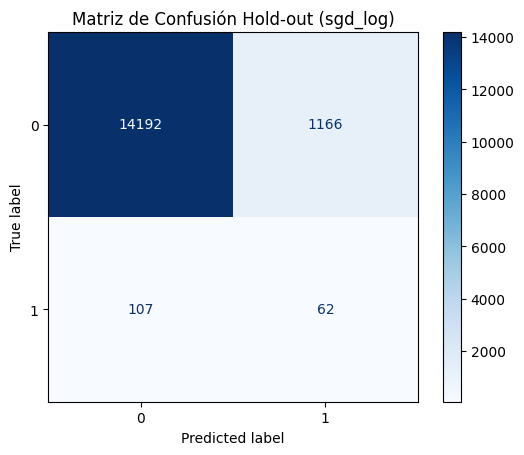

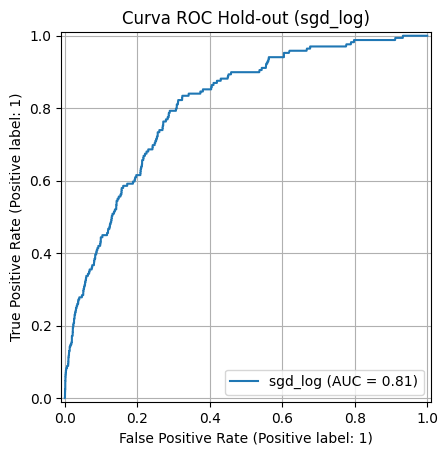

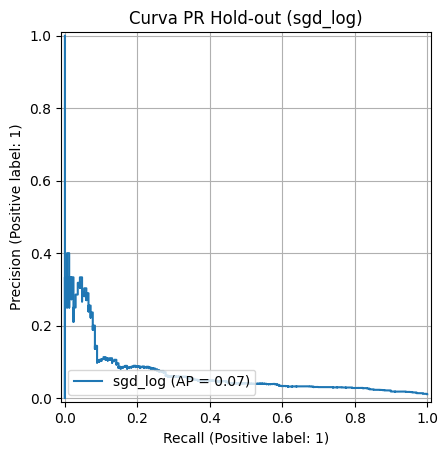

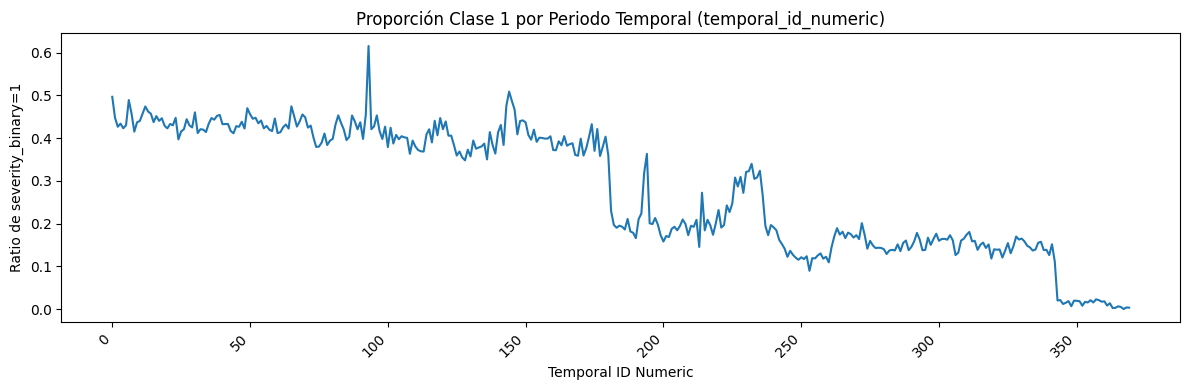


--- Proceso de modelado (estilo GPR) completado exitosamente! ---


In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# --- Helper Functions (from GPR scripts) ---
def parse_spatial_temporal_ids_for_gpr(df, temporal_raw_col='year_week', spatial_raw_col='zone_id'):
    df_copy = df.copy()
    if spatial_raw_col not in df_copy.columns:
        raise ValueError(f"Spatial ID column '{spatial_raw_col}' not found in input DataFrame.")
    df_copy['spatial_id'] = df_copy[spatial_raw_col].astype(str)

    if temporal_raw_col not in df_copy.columns:
        raise ValueError(f"Temporal ID column '{temporal_raw_col}' not found in input DataFrame.")
    unique_temporal_ids = sorted(df_copy[temporal_raw_col].unique())
    temporal_id_to_numeric_map = {yw: i for i, yw in enumerate(unique_temporal_ids)}
    df_copy['temporal_id_numeric'] = df_copy[temporal_raw_col].map(temporal_id_to_numeric_map)
    df_copy.sort_values(by=['spatial_id', 'temporal_id_numeric'], inplace=True)
    return df_copy

def clean_col_names_for_gpr(df, cols_to_clean):
    df_cleaned = df.copy()
    rename_map = {}
    cleaned_cols_list = []
    if not isinstance(cols_to_clean, list): cols_to_clean = []
    for col in cols_to_clean:
        if col is None or col not in df_cleaned.columns: continue
        new_col_name = str(col).replace('(F)', '_F') \
            .replace('(mph)', '_mph') \
            .replace('(in)', '_in') \
            .replace('(%)', '_percent') \
            .replace('[', '_').replace(']', '_') \
            .replace('(', '').replace(')', '') \
            .replace('%', 'percent').replace('/', '_').replace('-', '_') \
            .replace('.', '_')
        rename_map[col] = new_col_name
        cleaned_cols_list.append(new_col_name)
    df_cleaned.rename(columns=rename_map, inplace=True)
    return df_cleaned, cleaned_cols_list, rename_map

# --- Global Preprocessing Function ---
def preprocess_features_globally(df, covar_cols_to_use, numeric_strategy='mean'):
    processed_df = df.copy()
    valid_covar_cols = [col for col in covar_cols_to_use if col in processed_df.columns]

    if not valid_covar_cols:
        print("Warning: No valid covariate columns found to preprocess globally.")
        return processed_df, []

    processed_covar_names = []
    numeric_covars = processed_df[valid_covar_cols].select_dtypes(include=np.number).columns.tolist()
    categorical_covars = processed_df[valid_covar_cols].select_dtypes(exclude=np.number).columns.tolist()

    if numeric_covars:
        imputer_mean = SimpleImputer(strategy=numeric_strategy)
        scaler = StandardScaler()
        if processed_df[numeric_covars].isnull().values.any():
            processed_df[numeric_covars] = imputer_mean.fit_transform(processed_df[numeric_covars])
        if len(numeric_covars) > 0:
            processed_df[numeric_covars] = scaler.fit_transform(processed_df[numeric_covars])
        processed_covar_names.extend(numeric_covars)

    if categorical_covars:
        print(f"Warning: Categorical covariates found in global preprocessing: {categorical_covars}. Factorizing them.")
        imputer_mode = SimpleImputer(strategy='most_frequent')
        for col in categorical_covars:
            if processed_df[col].isnull().any():
                processed_df[col] = imputer_mode.fit_transform(processed_df[[col]]).ravel()
            processed_df[col] = pd.factorize(processed_df[col].astype(str))[0]
            processed_covar_names.append(col)
    
    final_processed_names = [col for col in valid_covar_cols if col in processed_df.columns and col in processed_covar_names]
    return processed_df, final_processed_names


print("--- Iniciando el entrenamiento del modelo de severidad (Benchmark vs GPR Setup) ---")
print("--- Cargando dataset YA PROCESADO ('revisedds.csv') ---")
print("--- Usando LTO Cross-Validation con SMOTE global en fold ---")

try:
    df_full_original = pd.read_csv('revisedds.csv')
except FileNotFoundError:
    print("ERROR: El archivo 'revisedds.csv' no se encontró. Verifica la ruta.")
    exit()

print(f"\nDataset 'revisedds.csv' cargado. Forma: {df_full_original.shape}")

target_col_name_original = 'severity_binary'
spatial_id_col_name_original = 'zone_id'
temporal_raw_col_name_original = 'year_week'

covariate_list_original = [
    'accident_count', 'Temperature(F)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Humidity(%)',
    'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal',
    'is_night', 'is_weekend', 'Temperature(F)_extreme', 'Wind_Speed(mph)_extreme',
    'Precipitation(in)_extreme', 'Humidity(%)_extreme',
    'Start_Lat', 'Start_Lng', 'lat_bin', 'lng_bin',
    'lat_min', 'lat_max', 'lng_min', 'lng_max',
]
covariate_list_original = [col for col in covariate_list_original if col in df_full_original.columns]

all_cols_to_clean_check = covariate_list_original + \
                          [target_col_name_original, spatial_id_col_name_original, temporal_raw_col_name_original]
all_cols_to_clean_check = list(set([col for col in all_cols_to_clean_check if col in df_full_original.columns]))

df_cleaned_names, _, raw_to_cleaned_map = clean_col_names_for_gpr(df_full_original.copy(), all_cols_to_clean_check)

target_col_cleaned = raw_to_cleaned_map.get(target_col_name_original, target_col_name_original)
spatial_id_col_for_parse = raw_to_cleaned_map.get(spatial_id_col_name_original, spatial_id_col_name_original)
temporal_raw_col_for_parse = raw_to_cleaned_map.get(temporal_raw_col_name_original, temporal_raw_col_name_original)

df_with_ids = parse_spatial_temporal_ids_for_gpr(
    df_cleaned_names.copy(),
    temporal_raw_col=temporal_raw_col_for_parse,
    spatial_raw_col=spatial_id_col_for_parse
)

if 'temporal_id_numeric' not in df_with_ids.columns:
    raise ValueError("'temporal_id_numeric' no fue creada. Revisa 'temporal_raw_col_for_parse'.")
if 'spatial_id' not in df_with_ids.columns:
    raise ValueError("'spatial_id' no fue creada. Revisa 'spatial_id_col_for_parse'.")

covariate_list_for_global_processing = [raw_to_cleaned_map.get(col, col) for col in covariate_list_original]
if 'temporal_id_numeric' not in covariate_list_for_global_processing:
    covariate_list_for_global_processing.append('temporal_id_numeric')
covariate_list_for_global_processing = [
    col for col in covariate_list_for_global_processing
    if col in df_with_ids.columns and col != target_col_cleaned
]
covariate_list_for_global_processing = sorted(list(set(covariate_list_for_global_processing)))

print(f"Covariables para preprocesamiento GLOBAL: {covariate_list_for_global_processing}")
df_globally_preprocessed, processed_covariate_names = preprocess_features_globally(
    df_with_ids.copy(),
    covariate_list_for_global_processing
)
print(f"Nombres de covariables procesadas GLOBALMENTE: {processed_covariate_names}")

if target_col_cleaned not in df_globally_preprocessed.columns:
    raise ValueError(f"La columna objetivo '{target_col_cleaned}' no está en el DataFrame preprocesado.")
y_series_full = df_globally_preprocessed[target_col_cleaned].astype(int)
X_df_full = df_globally_preprocessed.drop(columns=[target_col_cleaned], errors='ignore')

print(f"\nForma final de X para LTO: {X_df_full.shape}")
print(f"Forma final de y para LTO: {y_series_full.shape}")
print(f"Distribución de la clase objetivo (y_series_full):\n{y_series_full.value_counts(normalize=True)}")

if X_df_full.empty or y_series_full.empty:
    print("ERROR: X_df_full o y_series_full están vacíos antes de LTO. No se puede continuar.")
    exit()
if 'temporal_id_numeric' not in X_df_full.columns:
    raise ValueError("ERROR: 'temporal_id_numeric' falta en X_df_full antes de LTO.")

unique_temporal_ids = np.sort(X_df_full['temporal_id_numeric'].unique())
n_total_temporal_periods = len(unique_temporal_ids)
LTO_MAX_TRAIN_WINDOW_PERIODS = 26
n_splits_lto = 10

if n_total_temporal_periods <= LTO_MAX_TRAIN_WINDOW_PERIODS:
    exit(f"ERROR: Periodos temporales totales ({n_total_temporal_periods}) no es mayor que la ventana máx de entrenamiento ({LTO_MAX_TRAIN_WINDOW_PERIODS}).")

num_testable_periods_total = n_total_temporal_periods - LTO_MAX_TRAIN_WINDOW_PERIODS
if num_testable_periods_total < n_splits_lto:
    n_splits_lto = max(1, num_testable_periods_total)
    if n_splits_lto == 0: exit("ERROR: No quedan datos para folds de prueba.")
    print(f"ADVERTENCIA: n_splits_lto ajustado a {n_splits_lto} debido a datos insuficientes para prueba.")

test_fold_size_temporal_periods = num_testable_periods_total // n_splits_lto if n_splits_lto > 0 else 0
if test_fold_size_temporal_periods == 0 and num_testable_periods_total > 0:
    test_fold_size_temporal_periods = 1
if test_fold_size_temporal_periods == 0:
    exit("ERROR: No se pueden crear folds de prueba de tamaño 0.")

print(f"\n--- Iniciando LTO Cross-Validation con {n_splits_lto} folds (Ventana Deslizante) ---")
print(f"Tamaño máx ventana de entrenamiento: {LTO_MAX_TRAIN_WINDOW_PERIODS} periodos temporales")
print(f"Tamaño fold de prueba: {test_fold_size_temporal_periods} periodos temporales")

gp_feature_set_to_use = [
    'temporal_id_numeric',
    raw_to_cleaned_map.get('accident_count', 'accident_count'),
    raw_to_cleaned_map.get('Temperature(F)', 'Temperature_F'),
    raw_to_cleaned_map.get('Precipitation(in)', 'Precipitation_in'),
    raw_to_cleaned_map.get('is_night', 'is_night'),
    raw_to_cleaned_map.get('is_weekend', 'is_weekend')
]
gp_feature_set_to_use = [f for f in gp_feature_set_to_use if f in X_df_full.columns]
gp_feature_set_to_use = sorted(list(set(gp_feature_set_to_use)))

if not gp_feature_set_to_use:
    raise ValueError("ERROR: `gp_feature_set_to_use` está vacía o las características no se encontraron en X_df_full.")
print(f"Características seleccionadas para los modelos: {gp_feature_set_to_use}")

pos_weight_scale = (y_series_full == 0).sum() / (y_series_full == 1).sum() if (y_series_full == 1).sum() > 0 else 1
model_defs = {
    'rf': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample'),
    'xgb': XGBClassifier(random_state=42, tree_method='hist', n_jobs=-1, scale_pos_weight=pos_weight_scale),
    'logreg': LogisticRegression(max_iter=1000, solver='saga', random_state=42, n_jobs=-1, class_weight='balanced', penalty='l1'),
    'sgd_log': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced', early_stopping=True, n_iter_no_change=10, validation_fraction=0.1),
    'gaussian_nb': GaussianNB(),
    'knn': KNeighborsClassifier(n_neighbors=11, n_jobs=-1, weights='distance')
}

smote_sampling_strategy = 0.5
smote_k_neighbors = 5

model_predictions_aggregated = {model_name: {'y_true': [], 'y_pred': [], 'y_proba': [], 'name': model_name} for model_name in model_defs.keys()}
all_fold_model_metrics = []

for i in range(n_splits_lto):
    fold_start_time = time.time()
    print(f"\n=== Procesando LTO Fold {i+1}/{n_splits_lto} ===")

    current_test_start_idx_in_unique_ids = LTO_MAX_TRAIN_WINDOW_PERIODS + (i * test_fold_size_temporal_periods)
    current_test_end_idx_in_unique_ids = current_test_start_idx_in_unique_ids + test_fold_size_temporal_periods
    if i == n_splits_lto - 1:
        current_test_end_idx_in_unique_ids = n_total_temporal_periods
    
    current_test_temporal_ids = unique_temporal_ids[current_test_start_idx_in_unique_ids : current_test_end_idx_in_unique_ids]
    if len(current_test_temporal_ids) == 0:
        print("Fold de prueba vacío.")
        continue

    train_window_end_temporal_id_exclusive_val = current_test_temporal_ids.min()
    idx_train_end = np.searchsorted(unique_temporal_ids, train_window_end_temporal_id_exclusive_val)
    idx_train_start = max(0, idx_train_end - LTO_MAX_TRAIN_WINDOW_PERIODS)
    train_window_start_temporal_id_inclusive_val = unique_temporal_ids[idx_train_start]

    current_train_temporal_ids = unique_temporal_ids[
        (unique_temporal_ids >= train_window_start_temporal_id_inclusive_val) &
        (unique_temporal_ids < train_window_end_temporal_id_exclusive_val)
    ]
    if len(current_train_temporal_ids) == 0:
        print("Fold de entrenamiento vacío.")
        continue

    train_mask = X_df_full['temporal_id_numeric'].isin(current_train_temporal_ids)
    test_mask = X_df_full['temporal_id_numeric'].isin(current_test_temporal_ids)

    X_train_fold_full_features = X_df_full[train_mask].copy()
    y_train_fold_series = y_series_full[train_mask].copy()
    X_test_fold_full_features = X_df_full[test_mask].copy()
    y_test_fold_series = y_series_full[test_mask].copy()
    
    print(f"   Entrenar en {len(current_train_temporal_ids)} periodos temporales únicos (de {current_train_temporal_ids.min() if len(current_train_temporal_ids)>0 else 'N/A'} a {current_train_temporal_ids.max() if len(current_train_temporal_ids)>0 else 'N/A'})")
    print(f"   Probar en {len(current_test_temporal_ids)} periodos temporales únicos (de: {current_test_temporal_ids.min()} a {current_test_temporal_ids.max()})")
    print(f"   Muestras de entrenamiento (antes de selección de feat.): {len(X_train_fold_full_features)}, Muestras de prueba: {len(X_test_fold_full_features)}")

    if len(X_train_fold_full_features) < 10 or y_train_fold_series.nunique() < 2:
        print("   Saltando fold: datos insuficientes o solo una clase.")
        continue

    X_train_selected_features = X_train_fold_full_features[gp_feature_set_to_use]
    X_test_selected_features = X_test_fold_full_features[gp_feature_set_to_use]
    
    print(f"   Forma de X_train después de seleccionar características: {X_train_selected_features.shape}")
    print(f"   Distribución y_train_fold_series (antes de SMOTE):\n{y_train_fold_series.value_counts(normalize=True).to_dict()}")

    X_train_smoted, y_train_smoted = X_train_selected_features, y_train_fold_series
    minority_count_train = y_train_fold_series.value_counts().min()
    k_neigh_actual_smote = min(smote_k_neighbors, minority_count_train - 1) if minority_count_train > 1 else 1

    if k_neigh_actual_smote >= 1 and minority_count_train > k_neigh_actual_smote :
        print(f"   Aplicando SMOTE (k={k_neigh_actual_smote}, strategy={smote_sampling_strategy})...")
        smote_applicator = SMOTE(sampling_strategy=smote_sampling_strategy, random_state=42, k_neighbors=k_neigh_actual_smote)
        try:
            X_train_smoted, y_train_smoted = smote_applicator.fit_resample(X_train_selected_features, y_train_fold_series)
            print(f"   Forma de X_train después de SMOTE: {X_train_smoted.shape}")
            print(f"   Distribución y_train_smoted:\n{pd.Series(y_train_smoted).value_counts(normalize=True).to_dict()}")
        except ValueError as e_smote:
            print(f"   Error durante SMOTE: {e_smote}. Usando datos originales para este fold.")
            X_train_smoted, y_train_smoted = X_train_selected_features, y_train_fold_series
    else:
        print(f"   SMOTE no aplicable o no necesario (minority_count={minority_count_train}, k_neigh={k_neigh_actual_smote}). Usando datos originales.")

    for model_name, clf_instance in model_defs.items():
        print(f"      Entrenando {model_name}...")
        pipeline_start_time = time.time()
        
        current_clf = type(clf_instance)()
        current_clf.set_params(**clf_instance.get_params())

        try:
            current_clf.fit(X_train_smoted, y_train_smoted)
            fit_end_time = time.time()
            print(f"         Ajuste de {model_name} tomó: {fit_end_time - pipeline_start_time:.2f} segundos")

            y_pred_test = current_clf.predict(X_test_selected_features)
            y_proba_test = None
            if hasattr(current_clf, 'predict_proba'):
                y_proba_test = current_clf.predict_proba(X_test_selected_features)[:,1]
            elif hasattr(current_clf, 'decision_function'):
                y_proba_test = current_clf.decision_function(X_test_selected_features)
                if y_proba_test is not None and (y_proba_test.min() < 0 or y_proba_test.max() > 1):
                    y_proba_test = (y_proba_test - y_proba_test.min()) / (y_proba_test.max() - y_proba_test.min()) if (y_proba_test.max() - y_proba_test.min()) > 0 else np.full_like(y_proba_test, 0.5)


            f1 = f1_score(y_test_fold_series, y_pred_test, zero_division=0)
            roc = np.nan
            if y_proba_test is not None and y_test_fold_series.nunique() > 1 :
                try: roc = roc_auc_score(y_test_fold_series, y_proba_test)
                except ValueError as e_roc:
                    print(f"         Error calculando ROC AUC para {model_name}: {e_roc}")
                    roc = np.nan
            acc = accuracy_score(y_test_fold_series, y_pred_test)

            model_predictions_aggregated[model_name]['y_true'].extend(y_test_fold_series.tolist())
            model_predictions_aggregated[model_name]['y_pred'].extend(y_pred_test.tolist())
            if y_proba_test is not None:
                if isinstance(y_proba_test, (np.ndarray, pd.Series)):
                    model_predictions_aggregated[model_name]['y_proba'].extend(y_proba_test.tolist())
                else:
                    model_predictions_aggregated[model_name]['y_proba'].extend([y_proba_test] * len(y_pred_test))
            else:
                model_predictions_aggregated[model_name]['y_proba'].extend([np.nan] * len(y_pred_test))

            all_fold_model_metrics.append({
                'fold': i+1, 'model': model_name,
                'f1': f1, 'roc_auc': roc, 'accuracy': acc,
                'train_samples_smoted': len(y_train_smoted),
                'test_samples': len(y_test_fold_series)
            })
            print(f"      {model_name} -> F1: {f1:.4f}, ROC_AUC: {roc:.4f}, Acc: {acc:.4f}")

        except Exception as e_model:
            print(f"      ERROR entrenando/evaluando {model_name}: {e_model}")
            all_fold_model_metrics.append({
                'fold': i+1, 'model': model_name,
                'f1': np.nan, 'roc_auc': np.nan, 'accuracy': np.nan,
                'train_samples_smoted': len(y_train_smoted) if 'y_train_smoted' in locals() else len(X_train_selected_features),
                'test_samples': len(y_test_fold_series)
            })
    print(f"--- Fold {i+1} completado en {time.time() - fold_start_time:.2f} segundos ---")

if all_fold_model_metrics:
    df_all_fold_model_metrics = pd.DataFrame(all_fold_model_metrics)
    print("\n--- Promedio de Métricas LTO por Modelo (Media y Desviación Estándar) ---")
    average_model_performance = df_all_fold_model_metrics.groupby('model')[['f1','roc_auc','accuracy']].agg(['mean', 'std'])
    print(average_model_performance.sort_values(by=('roc_auc', 'mean'), ascending=False))

    best_model_name_avg = None
    if not average_model_performance[('roc_auc', 'mean')].dropna().empty:
        best_model_name_avg = average_model_performance[('roc_auc', 'mean')].idxmax()
        print(f"\nMejor modelo en promedio (basado en media de ROC_AUC en LTO): {best_model_name_avg}")
        print("Métricas promedio del mejor modelo (media y std):")
        print(average_model_performance.loc[best_model_name_avg])
    else:
        print("\nNo hay métricas ROC_AUC válidas de LTO para seleccionar mejor modelo promedio. Usando RandomForest por defecto para Hold-out.")
        best_model_name_avg = 'rf'
        if best_model_name_avg in average_model_performance.index:
             print("Métricas promedio del modelo fallback (RandomForest):")
             print(average_model_performance.loc[best_model_name_avg])
    
    # --- Visualización Agregada del Rendimiento de Cada Modelo (Todos los Folds LTO Combinados) ---
    print("\n\n--- ANÁLISIS VISUAL DEL RENDIMIENTO AGREGADO POR MODELO (SOBRE TODOS LOS FOLDS LTO) ---")

    fig_roc_all, ax_roc_all = plt.subplots(figsize=(12, 10)) # Ajuste tamaño
    ax_roc_all.plot([0, 1], [0, 1], 'k--', label='Suerte (AUC = 0.5)')

    fig_pr_all, ax_pr_all = plt.subplots(figsize=(12, 10)) # Ajuste tamaño
    temp_all_y_true_for_baseline = []
    for model_key_for_baseline in model_predictions_aggregated:
        temp_all_y_true_for_baseline.extend(model_predictions_aggregated[model_key_for_baseline]['y_true'])
    if temp_all_y_true_for_baseline:
        no_skill_pr = len([x for x in temp_all_y_true_for_baseline if x == 1]) / len(temp_all_y_true_for_baseline) if len(temp_all_y_true_for_baseline) > 0 else 0.0
        ax_pr_all.plot([0, 1], [no_skill_pr, no_skill_pr], 'k--', label=f'No Skill (AP = {no_skill_pr:.2f})')
    del temp_all_y_true_for_baseline


    for model_name_viz, data_viz in model_predictions_aggregated.items():
        print(f"\n--- Modelo: {data_viz['name']} (Rendimiento Agregado LTO) ---")
        
        y_true_agg_viz = np.array(data_viz['y_true'])
        y_pred_agg_viz = np.array(data_viz['y_pred'])
        y_proba_agg_viz = np.array(data_viz['y_proba'])

        if len(y_true_agg_viz) == 0 or len(y_pred_agg_viz) == 0:
            print("  No hay predicciones agregadas para mostrar para este modelo.")
            continue

        unique_labels_viz = sorted(list(np.unique(y_true_agg_viz)))
        if not unique_labels_viz or len(unique_labels_viz) < 2: # Asegurar al menos dos etiquetas para métricas binarias
            unique_labels_viz = [0, 1] 
        target_names_viz = [f"Clase {l}" for l in unique_labels_viz]

        print("  Reporte de Clasificación (Agregado LTO):")
        try:
            print(classification_report(y_true_agg_viz, y_pred_agg_viz, labels=unique_labels_viz, target_names=target_names_viz, zero_division=0))
        except Exception as e_cr_viz:
            print(f"    No se pudo generar el reporte de clasificación agregado: {e_cr_viz}")

        try:
            cm_agg_viz = confusion_matrix(y_true_agg_viz, y_pred_agg_viz, labels=unique_labels_viz)
            disp_cm_viz = ConfusionMatrixDisplay(confusion_matrix=cm_agg_viz, display_labels=unique_labels_viz)
            disp_cm_viz.plot(cmap='Blues')
            plt.title(f'Matriz de Confusión Agregada LTO - Modelo: {data_viz["name"]}')
            plt.show()
        except Exception as e_cm_viz:
            print(f"    No se pudo generar la matriz de confusión agregada para {data_viz['name']}: {e_cm_viz}")

        valid_proba_indices_viz = ~np.isnan(y_proba_agg_viz)
        y_true_for_curves_viz = y_true_agg_viz[valid_proba_indices_viz]
        y_proba_for_curves_viz = y_proba_agg_viz[valid_proba_indices_viz]

        if len(y_proba_for_curves_viz) == 0 or len(y_true_for_curves_viz) == 0:
            print(f"    No hay probabilidades válidas para curvas ROC/PR para {data_viz['name']}.")
        
        roc_auc_agg_value = np.nan
        if np.unique(y_true_for_curves_viz).size > 1 and len(y_proba_for_curves_viz) > 0:
            try:
                roc_auc_agg_value = roc_auc_score(y_true_for_curves_viz, y_proba_for_curves_viz)
                fig_roc_ind, ax_roc_ind = plt.subplots()
                RocCurveDisplay.from_predictions(y_true_for_curves_viz, y_proba_for_curves_viz, name=f"{data_viz['name']} (AUC={roc_auc_agg_value:.2f})", ax=ax_roc_ind)
                ax_roc_ind.plot([0, 1], [0, 1], 'k--')
                ax_roc_ind.set_title(f'Curva ROC Agregada LTO - Modelo: {data_viz["name"]}')
                plt.show()
                RocCurveDisplay.from_predictions(y_true_for_curves_viz, y_proba_for_curves_viz, name=f"{data_viz['name']} (AUC={roc_auc_agg_value:.2f})", ax=ax_roc_all)
            except ValueError as e_roc_viz_val:
                 print(f"    Advertencia Curva ROC para {data_viz['name']}: {e_roc_viz_val}.")
            except Exception as e_roc_viz:
                print(f"    No se pudo generar la curva ROC agregada para {data_viz['name']}: {e_roc_viz}")
        elif len(y_proba_for_curves_viz) > 0 :
             print(f"    No se puede generar la curva ROC para {data_viz['name']} (solo una clase presente en y_true después de filtrar NaNs en y_proba, o no hay suficientes muestras).")
        
        pos_label_viz = 1 if 1 in unique_labels_viz else (unique_labels_viz[-1] if unique_labels_viz else 1)
        if np.unique(y_true_for_curves_viz).size > 1 and pos_label_viz in np.unique(y_true_for_curves_viz) and len(y_proba_for_curves_viz) > 0:
            try:
                fig_pr_ind, ax_pr_ind = plt.subplots()
                PrecisionRecallDisplay.from_predictions(y_true_for_curves_viz, y_proba_for_curves_viz, name=f"{data_viz['name']}", pos_label=pos_label_viz, ax=ax_pr_ind)
                ax_pr_ind.set_title(f'Curva PR Agregada LTO - Modelo: {data_viz["name"]}')
                plt.show()
                PrecisionRecallDisplay.from_predictions(y_true_for_curves_viz, y_proba_for_curves_viz, name=f"{data_viz['name']}", pos_label=pos_label_viz, ax=ax_pr_all)
            except ValueError as e_pr_viz_val:
                 print(f"    Advertencia Curva PR para {data_viz['name']}: {e_pr_viz_val}.")
            except Exception as e_pr_viz:
                print(f"    No se pudo generar la curva PR agregada para {data_viz['name']}: {e_pr_viz}")
        elif len(y_proba_for_curves_viz) > 0 :
             print(f"    No se puede generar la curva PR para {data_viz['name']} (solo una clase presente en y_true, etiqueta positiva no encontrada, o no hay suficientes muestras).")

    ax_roc_all.set_title('Curvas ROC Comparativas (Rendimiento Agregado LTO)')
    ax_roc_all.legend(loc='lower right')
    ax_roc_all.grid(True)
    fig_roc_all.tight_layout()
    plt.show()

    ax_pr_all.set_title('Curvas Precision-Recall Comparativas (Rendimiento Agregado LTO)')
    ax_pr_all.legend(loc='best')
    ax_pr_all.grid(True)
    fig_pr_all.tight_layout()
    plt.show()

    # --- Hold-out Final ---
    if best_model_name_avg and best_model_name_avg in model_defs:
        best_clf_final_proto = model_defs[best_model_name_avg]
    else:
        print(f"ADVERTENCIA: El mejor modelo promedio '{best_model_name_avg}' no se encontró en model_defs o no fue determinado. Usando RandomForest por defecto para hold-out.")
        best_model_name_avg = 'rf'
        best_clf_final_proto = model_defs[best_model_name_avg]

    best_clf_final = type(best_clf_final_proto)()
    best_clf_final.set_params(**best_clf_final_proto.get_params())

    HOLDOUT_PERIODS = 13
    if n_total_temporal_periods <= HOLDOUT_PERIODS:
        print("No hay suficientes periodos para un hold-out separado con la configuración actual. Saltando hold-out.")
    else:
        holdout_start_temporal_id_idx = n_total_temporal_periods - HOLDOUT_PERIODS
        holdout_start_temporal_id = unique_temporal_ids[holdout_start_temporal_id_idx]

        mask_hold_final = X_df_full['temporal_id_numeric'] >= holdout_start_temporal_id
        mask_retrain_final = X_df_full['temporal_id_numeric'] < holdout_start_temporal_id

        X_hold_final_full_features = X_df_full[mask_hold_final]
        y_hold_final_series = y_series_full[mask_hold_final]
        X_retrain_final_full_features = X_df_full[mask_retrain_final]
        y_retrain_final_series = y_series_full[mask_retrain_final]

        print(f"\n--- Preparando Reentrenamiento para Hold-out Final ({best_model_name_avg}) ---")
        print(f"Datos de reentrenamiento: hasta antes del periodo temporal_id {holdout_start_temporal_id} ({len(X_retrain_final_full_features)} muestras)")
        print(f"Datos de Hold-out: desde el periodo temporal_id {holdout_start_temporal_id} en adelante ({len(X_hold_final_full_features)} muestras)")

        if X_retrain_final_full_features.empty or y_retrain_final_series.empty or X_hold_final_full_features.empty or y_hold_final_series.empty:
            print("ERROR: Conjuntos de reentrenamiento o hold-out vacíos. No se puede continuar con hold-out.")
        else:
            X_retrain_selected_features = X_retrain_final_full_features[gp_feature_set_to_use]
            X_hold_selected_features = X_hold_final_full_features[gp_feature_set_to_use]

            X_retrain_smoted, y_retrain_smoted = X_retrain_selected_features, y_retrain_final_series
            minority_count_retrain = y_retrain_final_series.value_counts().min()
            k_neigh_actual_smote_final = min(smote_k_neighbors, minority_count_retrain - 1) if minority_count_retrain > 1 else 1
            
            if k_neigh_actual_smote_final >=1 and minority_count_retrain > k_neigh_actual_smote_final:
                print(f"   Aplicando SMOTE al conjunto de reentrenamiento final (k={k_neigh_actual_smote_final}, strategy={smote_sampling_strategy})...")
                smote_final = SMOTE(sampling_strategy=smote_sampling_strategy, random_state=42, k_neighbors=k_neigh_actual_smote_final)
                try:
                    X_retrain_smoted, y_retrain_smoted = smote_final.fit_resample(X_retrain_selected_features, y_retrain_final_series)
                except ValueError as e_smote_final:
                    print(f"   Error SMOTE en reentrenamiento final: {e_smote_final}. Usando datos originales.")
                    X_retrain_smoted, y_retrain_smoted = X_retrain_selected_features, y_retrain_final_series
            else:
                print("   SMOTE no aplicable o no necesario para reentrenamiento final.")

            print(f"Reentrenando {best_model_name_avg} en {len(X_retrain_smoted)} muestras (después de SMOTE)...")
            best_clf_final.fit(X_retrain_smoted, y_retrain_smoted)

            print("\n--- Evaluación del Hold-out Final ---")
            y_hold_pred_final = best_clf_final.predict(X_hold_selected_features)
            
            final_unique_labels = sorted(list(np.unique(y_hold_final_series)))
            if not final_unique_labels or len(final_unique_labels) < 2: final_unique_labels = [0,1]
            final_target_names = [f"Clase {l}" for l in final_unique_labels]

            print(classification_report(y_hold_final_series, y_hold_pred_final, labels=final_unique_labels, target_names=final_target_names, zero_division=0))

            cm_final_labels = best_clf_final.classes_ if hasattr(best_clf_final, 'classes_') and len(best_clf_final.classes_)==2 else final_unique_labels
            cm_final = confusion_matrix(y_hold_final_series, y_hold_pred_final, labels=cm_final_labels)
            ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=cm_final_labels).plot(cmap=plt.cm.Blues)
            plt.title(f'Matriz de Confusión Hold-out ({best_model_name_avg})'); plt.show()

            y_proba_hold_final = None
            if hasattr(best_clf_final, 'predict_proba'):
                y_proba_hold_final = best_clf_final.predict_proba(X_hold_selected_features)[:,1]
            elif hasattr(best_clf_final, 'decision_function'):
                y_proba_hold_final = best_clf_final.decision_function(X_hold_selected_features)
                if y_proba_hold_final is not None and (y_proba_hold_final.min() < 0 or y_proba_hold_final.max() > 1):
                    y_proba_hold_final = (y_proba_hold_final - y_proba_hold_final.min()) / (y_proba_hold_final.max() - y_proba_hold_final.min()) if (y_proba_hold_final.max() - y_proba_hold_final.min()) > 0 else np.full_like(y_proba_hold_final, 0.5)

            if y_proba_hold_final is not None and y_hold_final_series.nunique() > 1:
                RocCurveDisplay.from_predictions(y_hold_final_series, y_proba_hold_final, name=best_model_name_avg).ax_.set_title(f'Curva ROC Hold-out ({best_model_name_avg})'); plt.grid(True); plt.show()
                PrecisionRecallDisplay.from_predictions(y_hold_final_series, y_proba_hold_final, name=best_model_name_avg, pos_label=1).ax_.set_title(f'Curva PR Hold-out ({best_model_name_avg})'); plt.grid(True); plt.show()
            else:
                print("  No se pudieron generar curvas ROC/PR para Hold-out.")
else:
    print("No se generaron métricas LTO. El proceso de hold-out y visualización agregada se omitirá.")


# --- Gráfico de deriva semanal (del dataset original después de parsear IDs) ---
if not df_with_ids.empty and target_col_cleaned in df_with_ids.columns and 'temporal_id_numeric' in df_with_ids.columns:
    weekly_drift = df_with_ids.groupby('temporal_id_numeric')[target_col_cleaned].mean()
    plt.figure(figsize=(12,4))
    weekly_drift.plot()
    plt.title('Proporción Clase 1 por Periodo Temporal (temporal_id_numeric)')
    plt.xlabel('Temporal ID Numeric')
    plt.ylabel(f'Ratio de {target_col_cleaned}=1')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos en df_with_ids para generar el gráfico de deriva semanal.")

print("\n--- Proceso de modelado (estilo GPR) completado exitosamente! ---")